# Ames Housing Dataset – Data Visualization

This notebook performs exploratory data visualization on the **Ames Housing uncleaned dataset** using **Matplotlib** and **Seaborn**.

### Visualizations included
1. Dataset overview
2. Missing-value analysis
3. Distribution of SalePrice
4. SalePrice by Overall Quality
5. Gr Liv Area vs SalePrice
6. Correlation heatmap
7. Average SalePrice by Neighborhood
8. Distribution of house construction year
9. Distribution of living area
10. Boxplot of SalePrice by House Style


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load dataset
file_path = "AmesHousing_Uncleaned.xlsx"
df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully!
Shape: (3130, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,NaN,RL,NaN,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20.0,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20.0,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20.0,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60.0,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [7]:
# Dataset overview

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Total missing cells:", df.isna().sum().sum())
print("\nData types:")
display(df.dtypes)

print("\nBasic statistics:")
display(df.describe(include="all").T.head(20))


Number of rows: 3130
Number of columns: 82
Total missing cells: 17010

Data types:


Order               int64
PID                 int64
MS SubClass       float64
MS Zoning             str
Lot Frontage      float64
                   ...   
Mo Sold             int64
Yr Sold             int64
Sale Type             str
Sale Condition        str
SalePrice           int64
Length: 82, dtype: object


Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order,3130.0,NaN,NaN,NaN,1378.279553,884.085103,1.0,583.25,1365.5,2147.75,2930.0
PID,3130.0,NaN,NaN,NaN,706438380.9623,188257149.454466,526301100.0,528456685.0,535402160.0,906420102.5,1007100110.0
MS SubClass,3010.0,NaN,NaN,NaN,57.647841,42.683524,20.0,20.0,50.0,70.0,190.0
MS Zoning,3130,7,RL,2416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot Frontage,2511.0,NaN,NaN,NaN,69.045002,23.352247,21.0,58.0,68.0,80.0,313.0
Lot Area,3130.0,NaN,NaN,NaN,10101.000319,7731.509203,1300.0,7420.0,9410.5,11500.0,215245.0
Street,3130,2,Pave,3118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alley,203,2,Grvl,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot Shape,3130,4,Reg,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Land Contour,3130,4,Lvl,2827,NaN,NaN,NaN,NaN,NaN,NaN,NaN


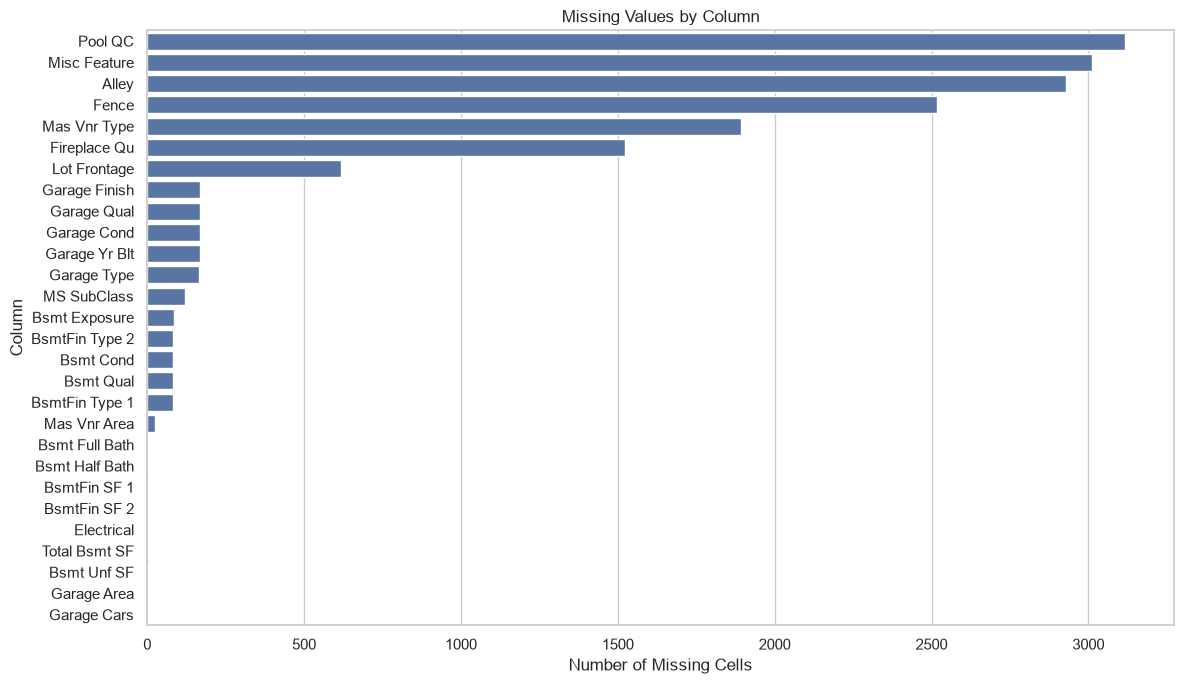

In [8]:
# 1. Missing values by column

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=missing.values, y=missing.index)
plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Cells")
plt.ylabel("Column")
plt.tight_layout()
plt.show()


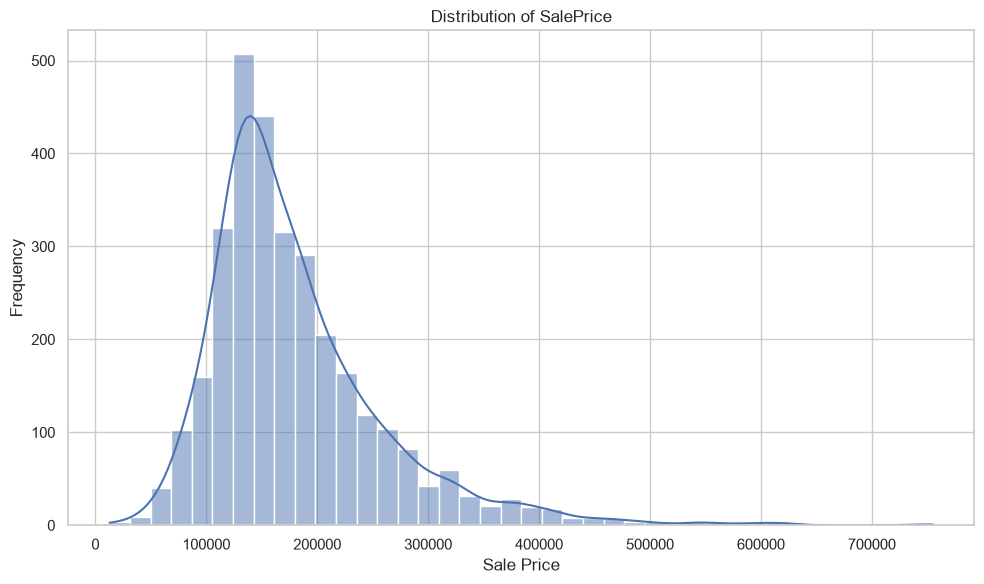

In [9]:
# 2. Distribution of SalePrice

plt.figure(figsize=(10, 6))
sns.histplot(df["SalePrice"].dropna(), kde=True, bins=40)
plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


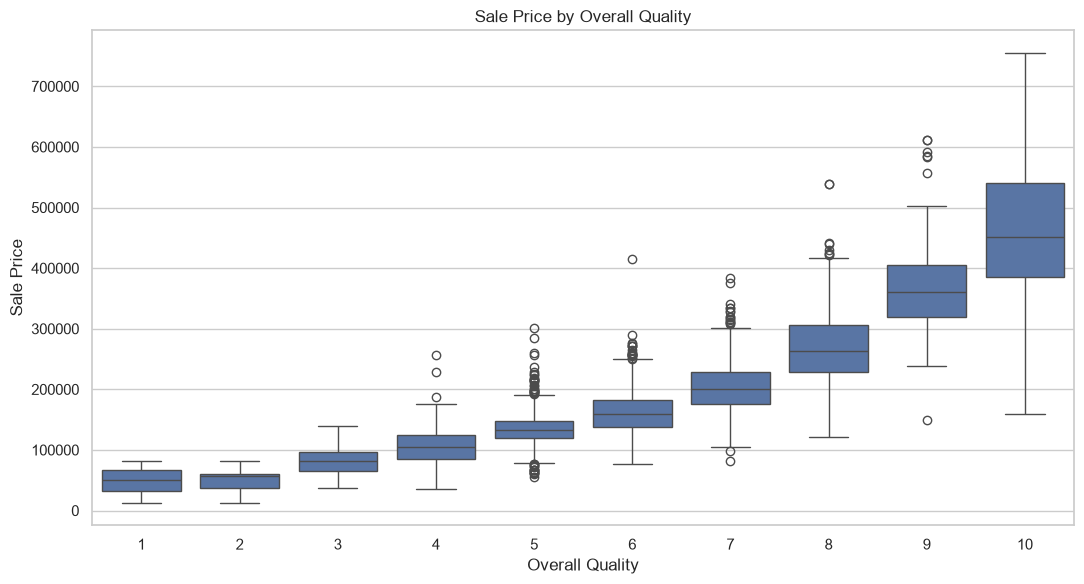

In [10]:
# 3. SalePrice by Overall Quality

plt.figure(figsize=(11, 6))
sns.boxplot(data=df, x="Overall Qual", y="SalePrice")
plt.title("Sale Price by Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.tight_layout()
plt.show()


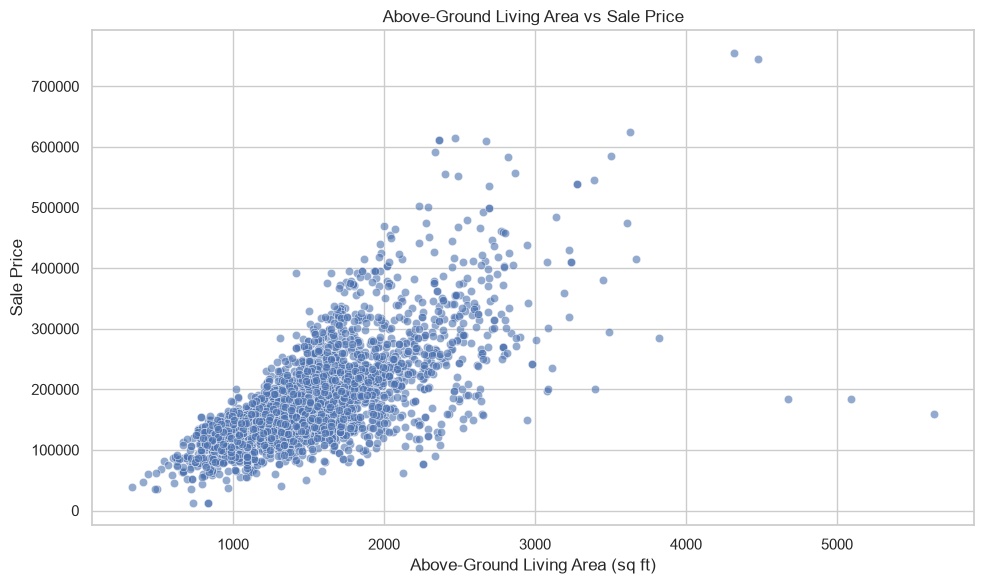

In [11]:
# 4. Gr Liv Area vs SalePrice

plot_df = df[["Gr Liv Area", "SalePrice"]].dropna()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x="Gr Liv Area", y="SalePrice", alpha=0.6)
plt.title("Above-Ground Living Area vs Sale Price")
plt.xlabel("Above-Ground Living Area (sq ft)")
plt.ylabel("Sale Price")
plt.tight_layout()
plt.show()


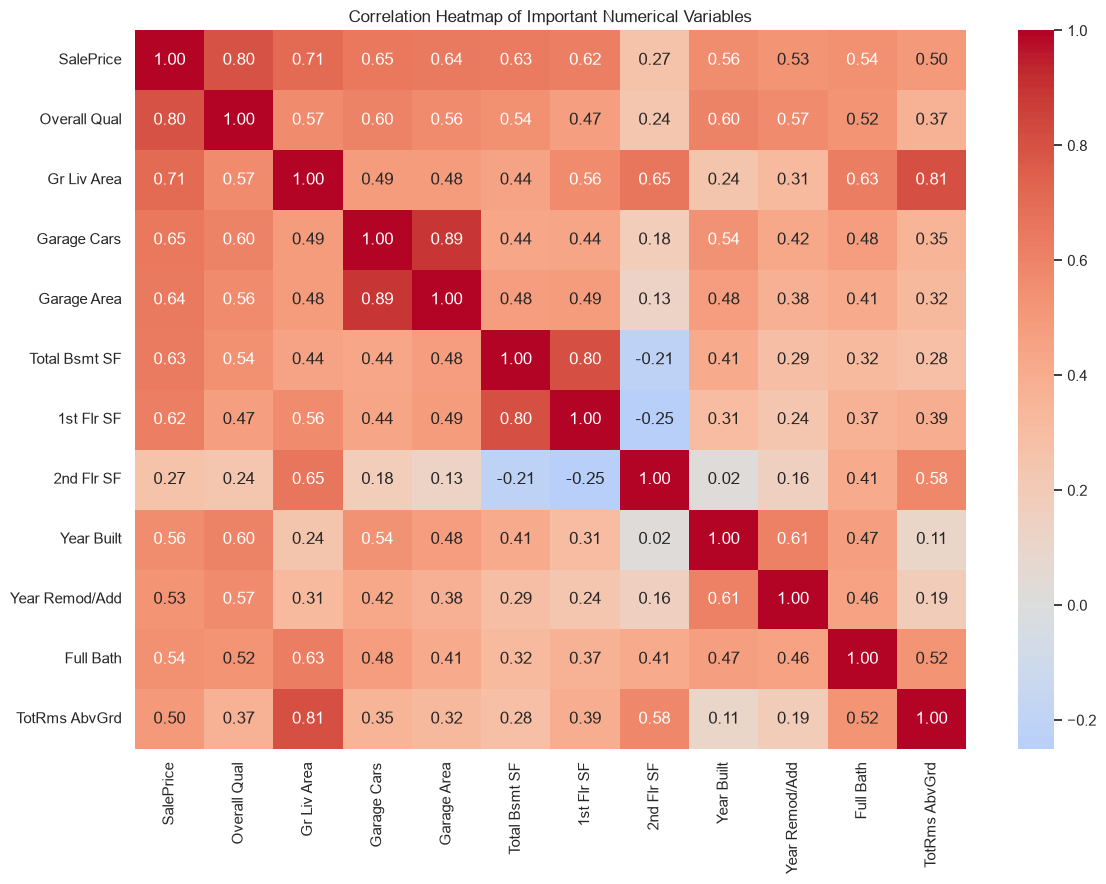

In [12]:
# 5. Correlation heatmap for important numerical variables

corr_cols = [
    "SalePrice", "Overall Qual", "Gr Liv Area", "Garage Cars",
    "Garage Area", "Total Bsmt SF", "1st Flr SF", "2nd Flr SF",
    "Year Built", "Year Remod/Add", "Full Bath", "TotRms AbvGrd"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Important Numerical Variables")
plt.tight_layout()
plt.show()


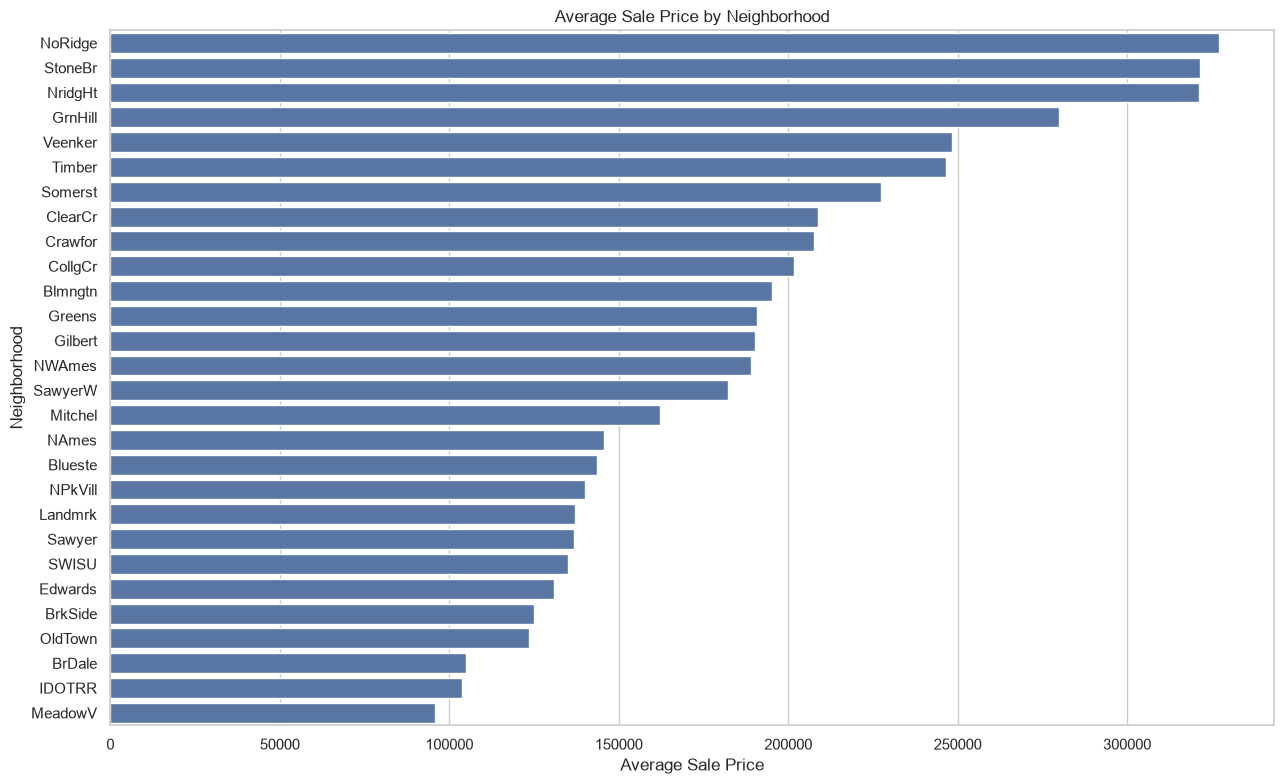

In [13]:
# 6. Average SalePrice by Neighborhood

neighborhood_price = (
    df.groupby("Neighborhood", dropna=False)["SalePrice"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(13, 8))
sns.barplot(x=neighborhood_price.values, y=neighborhood_price.index)
plt.title("Average Sale Price by Neighborhood")
plt.xlabel("Average Sale Price")
plt.ylabel("Neighborhood")
plt.tight_layout()
plt.show()


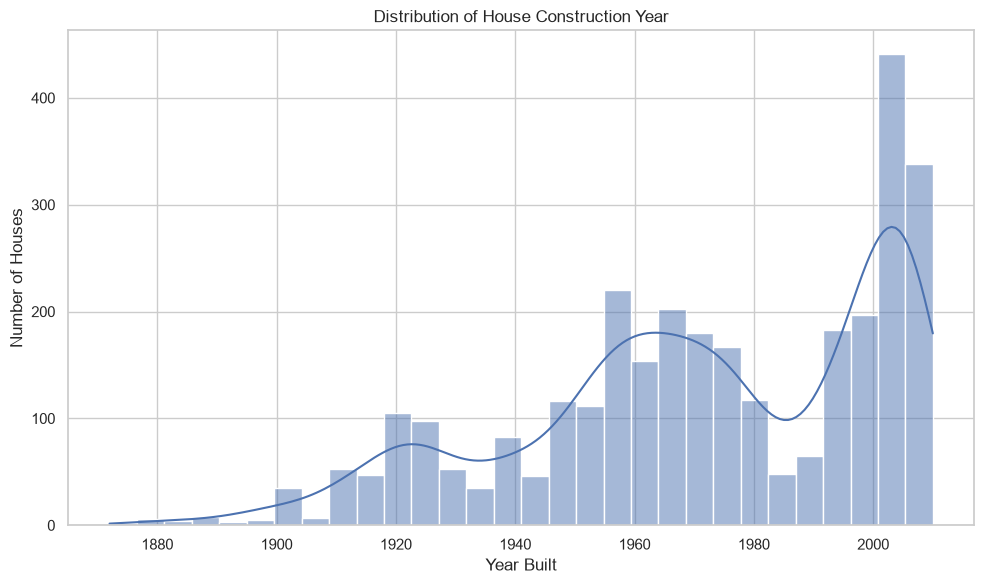

In [14]:
# 7. Distribution of Year Built

plt.figure(figsize=(10, 6))
sns.histplot(df["Year Built"].dropna(), bins=30, kde=True)
plt.title("Distribution of House Construction Year")
plt.xlabel("Year Built")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()


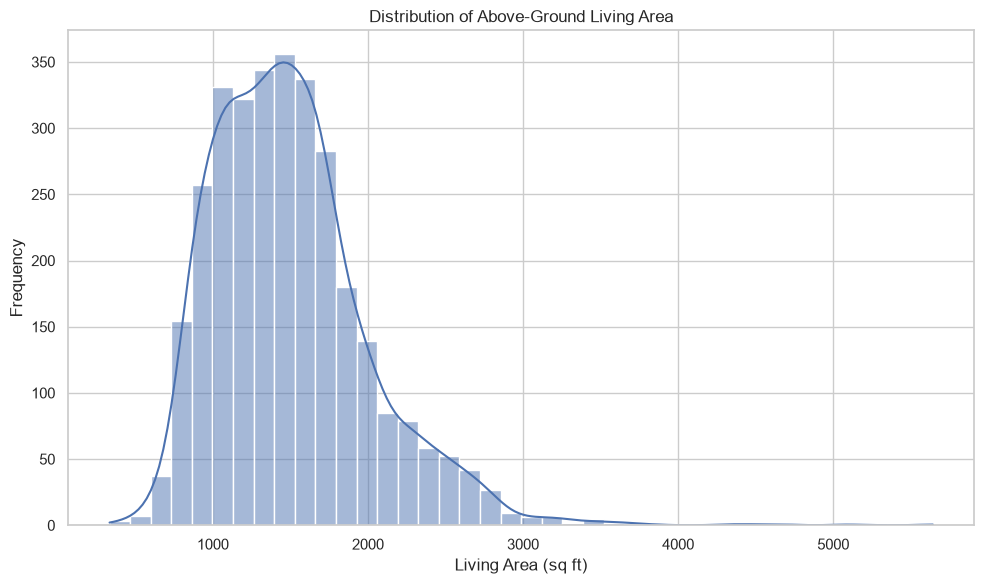

In [15]:
# 8. Distribution of Above-Ground Living Area

plt.figure(figsize=(10, 6))
sns.histplot(df["Gr Liv Area"].dropna(), bins=40, kde=True)
plt.title("Distribution of Above-Ground Living Area")
plt.xlabel("Living Area (sq ft)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


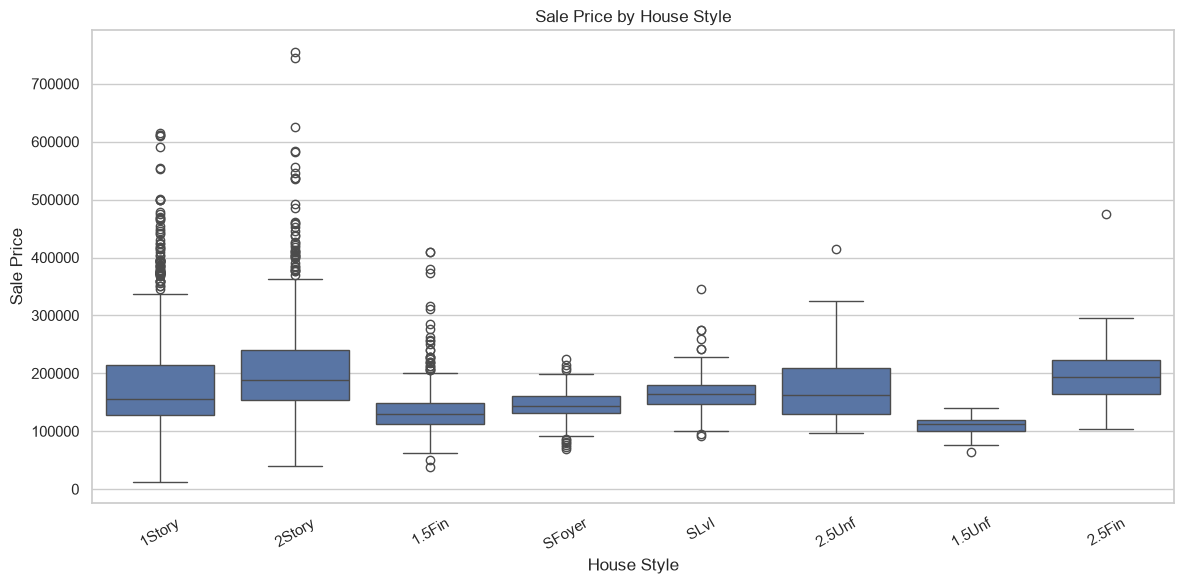

In [16]:
# 9. SalePrice by House Style

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="House Style", y="SalePrice")
plt.title("Sale Price by House Style")
plt.xlabel("House Style")
plt.ylabel("Sale Price")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Key Observations to Explore

- **SalePrice** is generally right-skewed, with a smaller number of high-priced properties.
- **Overall Qual** is strongly associated with house sale prices.
- **Gr Liv Area** generally has a positive relationship with **SalePrice**.
- The correlation heatmap helps identify numerical variables that may be useful for house-price prediction.
- Average house prices vary considerably between **Neighborhoods**.
- Construction year and living area provide useful information about the characteristics of the properties.
- Missing values should be handled carefully before further statistical analysis or machine-learning modeling.
